[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/chapter_06/chapter_06_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 6 — Model Selection and Regularisation
## Lab: subset selection, ridge, lasso, PCR, PLS

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal.** On the Hitters data, fit best-subset, ridge, lasso, PCR, and PLS, and compare them by cross-validation.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


## 1. Hitters data

Major-league batting records with `Salary` as the response. `dropna()` removes the 59 players whose salary is missing, leaving 263 — a small $n$ against 19 predictors after dummy coding, which is precisely the regime where selection and shrinkage earn their keep.

Note the predictors are heavily collinear by construction: `CAtBat`, `CHits`, `CRuns`, `CRBI` and `CWalks` are all career totals of a long career. Least squares handles that badly, and how each method copes with it is the real subject of this chapter.

In [2]:
Hitters = load('Hitters').dropna().reset_index(drop=True)
y = Hitters['Salary']
X = Hitters.drop(columns='Salary')
X = pd.get_dummies(X, drop_first=True).astype(float)
print(X.shape); X.head()


(263, 19)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
0,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,1.0,1.0,1.0
1,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,0.0,1.0,0.0
2,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,1.0,0.0,1.0
3,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,1.0,0.0,1.0
4,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,0.0,1.0,0.0


## 2. Best-subset and forward stepwise selection

Best subset asks, for each size $k$, which $k$ predictors give the lowest RSS — by fitting every combination. Forward stepwise starts empty and adds whichever single predictor most reduces RSS, never revisiting an earlier choice.

Note the cap at $k \le 5$ below. That is not a pedagogical simplification; it is a computational necessity, and §6 measures exactly how bad it gets.

In [3]:
import itertools, statsmodels.api as sm
from sklearn.metrics import mean_squared_error
preds = X.columns.tolist()
best = {}
for k in range(1, 6):
    best_rss, best_combo = None, None
    for combo in itertools.combinations(preds, k):
        rss = sm.OLS(y, sm.add_constant(X[list(combo)])).fit().ssr
        if best_rss is None or rss < best_rss:
            best_rss, best_combo = rss, combo
    best[k] = best_combo
best


{1: ('CRBI',),
 2: ('Hits', 'CRBI'),
 3: ('Hits', 'CRBI', 'PutOuts'),
 4: ('Hits', 'CRBI', 'PutOuts', 'Division_W'),
 5: ('AtBat', 'Hits', 'CRBI', 'PutOuts', 'Division_W')}

In [4]:
# Forward stepwise
remaining = preds.copy(); selected = []
for step in range(8):
    best_rss, best_v = None, None
    for v in remaining:
        rss = sm.OLS(y, sm.add_constant(X[selected + [v]])).fit().ssr
        if best_rss is None or rss < best_rss:
            best_rss, best_v = rss, v
    selected.append(best_v); remaining.remove(best_v)
    print(step + 1, '->', selected[-1], 'RSS =', round(best_rss, 1))


1 -> CRBI RSS = 36179679.3
2 -> Hits RSS = 30646559.9
3 -> PutOuts RSS = 29249296.9
4 -> Division_W RSS = 27970851.8
5 -> AtBat RSS = 27149899.4
6 -> Walks RSS = 26194903.9
7 -> CWalks RSS = 25954217.1
8 -> CRuns RSS = 25159233.9


**Reading the output.** RSS falls monotonically as predictors are added — it must, since adding a column can never increase the achievable RSS. That is why RSS cannot choose $k$, and why $C_p$, BIC and cross-validation exist.

Compare the two searches at $k = 5$: best subset picks `AtBat, Hits, CRBI, PutOuts, Division_W`, and forward stepwise arrives at the same five in the order `CRBI, Hits, PutOuts, Division_W, AtBat`. They agree here — but they need not, and that is the point. Forward stepwise commits to `CRBI` at step 1 and can never drop it, so a pair of predictors that only works *together* is invisible to it.

## 3. Ridge regression

Here and for the lasso below, the penalty is selected with the scaler nested *inside* the search: standardising all 263 rows first and only then letting `RidgeCV`/`LassoCV` split would score every candidate $\lambda$ on data whose means and standard deviations were computed with help from the very rows being held out.


In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, LeaveOneOut
alphas = np.logspace(-2, 4, 50)
ridge_cv = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),  # scaler per fold
                        {'ridge__alpha': alphas},
                        cv=LeaveOneOut(),      # RidgeCV's own default is leave-one-out
                        scoring='neg_mean_squared_error').fit(X, y)
ridge = ridge_cv.best_estimator_.named_steps['ridge']
print('best alpha:', ridge_cv.best_params_['ridge__alpha'])
print(pd.Series(ridge.coef_, index=X.columns).round(2))


best alpha: 2.8117686979742307
AtBat         -229.01
Hits           245.55
HmRun            4.61
Runs            -5.48
RBI              2.44
Walks          110.78
Years          -50.10
CAtBat        -115.25
CHits          123.26
CHmRun          56.29
CRuns          220.11
CRBI           120.98
CWalks        -154.21
PutOuts         77.87
Assists         40.90
Errors         -24.92
League_N        30.46
Division_W     -61.51
NewLeague_N    -13.75
dtype: float64


### Ridge coefficient paths


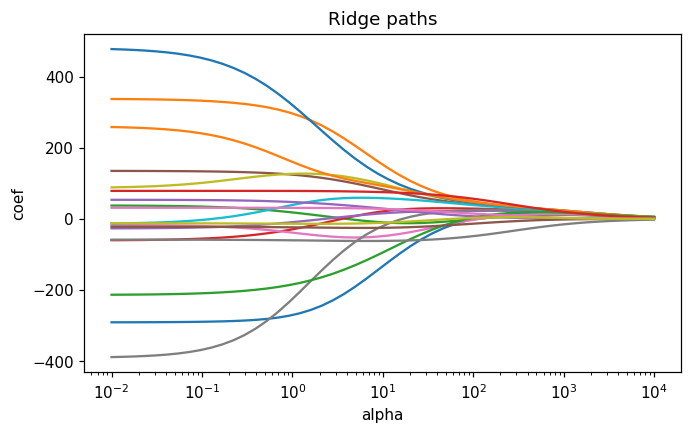

In [6]:
from sklearn.linear_model import Ridge
Xs = StandardScaler().fit_transform(X)
paths = np.array([Ridge(alpha=a).fit(Xs, y).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(7, 4))
for j, name in enumerate(X.columns):
    ax.plot(alphas, paths[:, j], label=name)
ax.set_xscale('log'); ax.set_xlabel('alpha'); ax.set_ylabel('coef')
ax.set_title('Ridge paths'); plt.show()


## 4. Lasso

Same objective as ridge with the penalty in $\ell_1$ rather than $\ell_2$: $\lambda\sum_j |\beta_j|$ instead of $\lambda\sum_j \beta_j^2$. That one change makes the difference between shrinking coefficients and **zeroing** them, so the lasso performs selection and shrinkage in a single fit.

Two implementation points that matter more than they look:

- `StandardScaler` is a step *inside* the pipeline, so it is re-fitted on each of the 10 CV folds. Scaling before the split would leak the validation folds' means into the training data.
- Penalising $|\beta_j|$ is only meaningful once the predictors share a scale — otherwise the penalty is a statement about units, not importance.

In [7]:
from sklearn.linear_model import Lasso
alphas = np.logspace(-3, 2, 50)
lasso_cv = GridSearchCV(make_pipeline(StandardScaler(), Lasso(max_iter=100000)),
                        {'lasso__alpha': alphas},   # scaler re-fit on each of the 10 folds
                        cv=10, scoring='neg_mean_squared_error').fit(X, y)
lasso = lasso_cv.best_estimator_.named_steps['lasso']
print('best alpha:', lasso_cv.best_params_['lasso__alpha'])
coefs = pd.Series(lasso.coef_, index=X.columns)
print('non-zero:', coefs[coefs != 0].round(2))


best alpha: 2.329951810515372
non-zero: AtBat        -243.56
Hits          266.12
HmRun           0.03
Walks         106.57
Years         -47.64
CHmRun         47.06
CRuns         230.24
CRBI          122.30
CWalks       -150.86
PutOuts        76.96
Assists        27.85
Errors        -14.46
League_N       16.38
Division_W    -59.59
dtype: float64


### Lasso paths


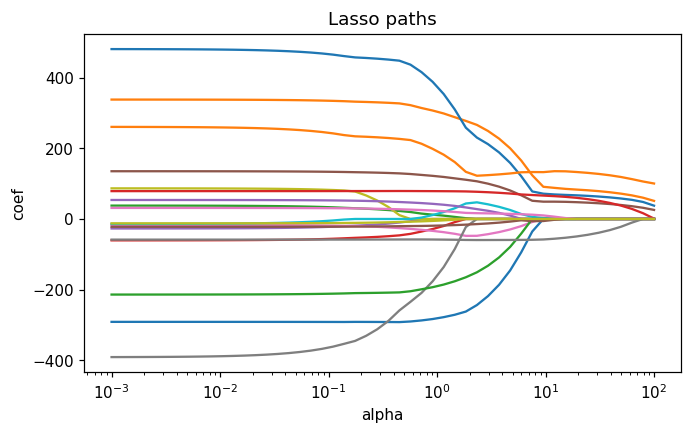

In [8]:
Xs = StandardScaler().fit_transform(X)
paths = np.array([Lasso(alpha=a, max_iter=10000).fit(Xs, y).coef_ for a in alphas])
fig, ax = plt.subplots(figsize=(7, 4))
for j in range(paths.shape[1]):
    ax.plot(alphas, paths[:, j])
ax.set_xscale('log'); ax.set_xlabel('alpha'); ax.set_ylabel('coef')
ax.set_title('Lasso paths'); plt.show()


## 5. PCR and PLS

Both replace the 19 predictors with a handful of linear combinations, and they differ in one crucial respect:

- **PCR** picks directions of maximum *predictor* variance. It never looks at $y$ — an unsupervised step glued to a supervised one, so nothing guarantees the leading components have anything to do with salary.
- **PLS** picks directions of maximum *covariance with $y$*, so it is supervised throughout.

Both are answers to the collinearity noted in §1: with career totals moving together, a few components carry nearly all the information in all 19 columns.

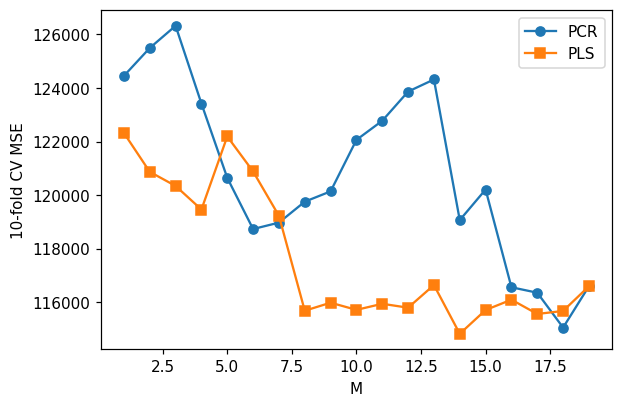

In [9]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
# StandardScaler is a step *inside* each pipeline, so cross_val_score re-fits it
# on every training fold; standardising X once up front would let each held-out
# fold help set the means and standard deviations used to train.
pcr_scores = []; pls_scores = []
for M in range(1, X.shape[1] + 1):
    pcr = make_pipeline(StandardScaler(), PCA(n_components=M), LinearRegression())
    pls = make_pipeline(StandardScaler(), PLSRegression(n_components=M, scale=False))
    pcr_scores.append(-cross_val_score(pcr, X, y, cv=10,
                                         scoring='neg_mean_squared_error').mean())
    pls_scores.append(-cross_val_score(pls, X, y, cv=10,
                                         scoring='neg_mean_squared_error').mean())
fig, ax = plt.subplots(figsize=(6, 4))
Ms = range(1, X.shape[1] + 1)
ax.plot(Ms, pcr_scores, marker='o', label='PCR')
ax.plot(Ms, pls_scores, marker='s', label='PLS')
ax.set(xlabel='M', ylabel='10-fold CV MSE'); ax.legend(); plt.show()


## 6. How many models did we skip?

The deck's Exercise 6.1 counts the search spaces. Best subset considers every subset of $p$ predictors,

$$\sum_{k=0}^{p} \binom{p}{k} = 2^{p},$$

while forward stepwise fits $p - k$ models at step $k$, giving $1 + p(p+1)/2$ in total. With $p = 19$ that gap is the reason §2 stopped at $k = 5$.

In [10]:
from math import comb

p = X.shape[1]
best_subset_total = 2 ** p
forward_total = 1 + p * (p + 1) // 2
actually_fitted = sum(comb(p, k) for k in range(1, 6))     # what section 2 really ran

print(f'predictors p                        : {p}')
print(f'best subset, all sizes  (2^p)       : {best_subset_total:,}')
print(f'what section 2 fitted   (k <= 5)    : {actually_fitted:,}')
print(f'forward stepwise, all sizes         : {forward_total:,}')
print()
print(f'best subset / forward stepwise      : {best_subset_total / forward_total:,.0f}x more models')

# The deck's worked case, p = 10.
p10 = 10
print(f'\ndeck example, p = 10: best subset {2 ** p10:,} vs forward {1 + p10 * (p10 + 1) // 2}')

predictors p                        : 19
best subset, all sizes  (2^p)       : 524,288
what section 2 fitted   (k <= 5)    : 16,663
forward stepwise, all sizes         : 191

best subset / forward stepwise      : 2,745x more models

deck example, p = 10: best subset 1,024 vs forward 56


**Reading the output.** With $p = 19$, best subset means **524,288** fits against forward stepwise's **191** — about 2,700 times more work — and even the truncated $k \le 5$ search in §2 fitted **16,663** models. The deck's $p = 10$ case is the gentler illustration: 1,024 against 56.

Two conclusions follow, and they are the reason the rest of the chapter exists. First, exhaustive search is not a strategy that scales; $p = 40$ is already a trillion models. Second, and less obvious: searching half a million models means the winner's training RSS is *optimistically biased* by the search itself, so the selected model must still be judged by CV on data the search never saw. Ridge and the lasso sidestep the combinatorial problem entirely by fitting one continuous path instead.

## 7. Exercises
1. Run *backward* stepwise selection and compare with forward.
2. Use the one-standard-error rule to choose a more parsimonious lasso $\lambda$.
3. Fit elastic net on Hitters with `ElasticNetCV`. How does it compare to ridge and lasso?
4. On a high-dimensional problem ($p > n$), demonstrate that OLS fails while ridge / lasso work.


## Lecture exercises — worked Python solutions

The cells below mirror the **[Python]-tagged exercises** from the Chapter 6 lecture slides, with fully worked, runnable solutions and the expected numeric answers (stored as inline comments). Each solution reloads `Hitters` through the `load()` helper so it stands alone and reproduces the slide numbers.

### Exercise 6.7 — CV ridge and lasso on Hitters

On the `Hitters` data (predict `Salary`): (i) fit the lasso with a cross-validated $\lambda$ on standardised predictors, (ii) report the selected $\lambda$, and (iii) list which features the lasso keeps versus drops. Contrast with ridge, which keeps every predictor.

In [11]:
# Exercise 6.7 -- lasso vs ridge with a cross-validated penalty on Hitters.
from sklearn.linear_model    import Lasso, Ridge
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import make_pipeline
from sklearn.model_selection import GridSearchCV

df    = load('Hitters').dropna()                 # drop the 59 rows with NA Salary
yH    = df['Salary'].values
X_raw = pd.get_dummies(df.drop(columns='Salary'),    # encode League/Division/NewLeague
                       drop_first=True).astype(float)
preds = X_raw.columns
print('n, p =', X_raw.shape)                     # (263, 19)

# Standardising matters (the penalty is scale-dependent), but it has to happen
# INSIDE the pipeline: GridSearchCV then re-fits the scaler on each training
# fold, so no validation fold ever helps set the scaling used to train.
lasso_cv = GridSearchCV(make_pipeline(StandardScaler(), Lasso(max_iter=100000)),
                        {'lasso__alpha': np.logspace(-3, 2, 50)},
                        cv=10, scoring='neg_mean_squared_error').fit(X_raw, yH)
lasso = lasso_cv.best_estimator_.named_steps['lasso']            # CV lambda
print('lasso alpha :', round(lasso_cv.best_params_['lasso__alpha'], 3))   # 2.33
kept    = [p for p, c in zip(preds, lasso.coef_) if abs(c) >  1e-8]
dropped = [p for p, c in zip(preds, lasso.coef_) if abs(c) <= 1e-8]
print('kept    :', kept)      # Hits, Walks, CRBI, PutOuts, Division_W, ...
print('dropped :', dropped)   # Runs, RBI, CAtBat, CHits, NewLeague_N

ridge_cv = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),   # same recipe
                        {'ridge__alpha': np.logspace(-2, 4, 50)},
                        cv=10, scoring='neg_mean_squared_error').fit(X_raw, yH)
ridge = ridge_cv.best_estimator_.named_steps['ridge']
print('ridge alpha :', round(ridge_cv.best_params_['ridge__alpha'], 3),
      '-- nonzero coefs:', int(np.sum(np.abs(ridge.coef_) > 1e-8)))   # 2.812 -- 19

n, p = (263, 19)


lasso alpha : 2.33
kept    : ['AtBat', 'Hits', 'HmRun', 'Walks', 'Years', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W']
dropped : ['Runs', 'RBI', 'CAtBat', 'CHits', 'NewLeague_N']


ridge alpha : 2.812 -- nonzero coefs: 19


**Interpretation.** The lasso selects a moderate $\lambda\approx2.33$ and drives several coefficients *exactly* to zero — it keeps strong career/recent-performance predictors (e.g. `Hits`, `Walks`, `CRBI`, `PutOuts`, `Division_W`) and drops weak or redundant ones (`Runs`, `RBI`, `CAtBat`, `CHits`, `NewLeague_N`). Ridge keeps all 19 predictors nonzero (it only shrinks). Takeaway: the lasso yields a sparse, more interpretable model via automatic variable selection, whereas ridge stabilises the fit while retaining every predictor. Note where the standardisation lives: it is a pipeline step that `GridSearchCV` re-fits on every training fold, because a scaler fitted once on the whole matrix has already seen each validation fold — the leakage the Chapter 5 lab warns about.

### Extended Exercise 6.3 — CV ridge and lasso *test* MSE on Hitters

Split `Hitters` into train/test, standardise using the **training set only** (no leakage), and cross-validate $\lambda$ for both ridge and lasso. Report each chosen $\lambda$, the *test* MSE, and how many coefficients are non-zero; list the predictors the lasso drops.

In [12]:
# Extended Exercise 6.3 -- honest test-MSE comparison with leak-free scaling.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import RidgeCV, LassoCV
from sklearn.metrics         import mean_squared_error

df  = load('Hitters').dropna(subset=['Salary'])  # drop rows with NA response
yH  = df['Salary'].values
XH  = pd.get_dummies(df.drop(columns='Salary'),
                     drop_first=True).astype(float)
Xtr, Xte, ytr, yte = train_test_split(XH.values, yH,
                        test_size=0.33, random_state=1)    # 2/3 - 1/3 split
sc = StandardScaler().fit(Xtr)                   # fit scaler on TRAIN only
Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)  # apply to both -> no leakage

ridge = RidgeCV(alphas=np.logspace(-2, 4, 50)).fit(Xtr, ytr)
lasso = LassoCV(cv=10, max_iter=100000, random_state=0).fit(Xtr, ytr)
for name, m in [('ridge', ridge), ('lasso', lasso)]:
    mse = mean_squared_error(yte, m.predict(Xte))        # TEST-set MSE
    nz  = int(np.sum(np.abs(m.coef_) > 1e-8))            # nonzero coefficients
    print(f'{name}: lambda={round(m.alpha_, 3)}  testMSE={round(mse, 0)}  nonzero={nz}')
    # ridge: lambda=0.095  testMSE=122695.0  nonzero=19
    # lasso: lambda=0.779  testMSE=119064.0  nonzero=16
dropped = [c for c, w in zip(XH.columns, lasso.coef_) if abs(w) <= 1e-8]
print('lasso drops:', dropped)                   # ['Years', 'CRBI', 'Errors']

ridge: lambda=0.095  testMSE=122695.0  nonzero=19
lasso: lambda=0.779  testMSE=119064.0  nonzero=16
lasso drops: ['Years', 'CRBI', 'Errors']


**Interpretation.** With $n=263$, $p=19$ and this split, ridge chooses $\lambda\approx0.1$ (test MSE $\approx1.2\times10^5$, all 19 coefficients non-zero) while the lasso chooses $\lambda\approx0.8$ (test MSE $\approx1.2\times10^5$, 16 non-zero) and drops `Years`, `CRBI`, `Errors` (weak or redundant given the correlated career totals). Both attain nearly identical test error, but the lasso reaches it with a *sparser, more interpretable* model. Exact numbers shift with the split/seed; the qualitative message — lasso selects, ridge keeps all — is stable.